Initial Population:

[8, 1, 7, 3, 5, 4, 2, 6] Fitness: 22
[7, 3, 2, 4, 6, 5, 8, 1] Fitness: 21
[5, 6, 2, 8, 7, 3, 1, 4] Fitness: 21
[3, 7, 8, 6, 2, 5, 1, 4] Fitness: 25
[2, 6, 7, 8, 1, 3, 5, 4] Fitness: 21
[1, 4, 7, 6, 5, 8, 2, 3] Fitness: 20
[2, 1, 6, 8, 4, 5, 7, 3] Fitness: 22
[4, 2, 5, 7, 3, 1, 6, 8] Fitness: 25
[4, 2, 5, 3, 1, 8, 6, 7] Fitness: 24
[4, 1, 5, 2, 8, 6, 7, 3] Fitness: 26
Generation 0 | Max Fitness = 26 | Avg Fitness = 22.70
Generation 1 | Max Fitness = 26 | Avg Fitness = 22.80
Generation 2 | Max Fitness = 26 | Avg Fitness = 23.40
Generation 3 | Max Fitness = 26 | Avg Fitness = 24.00
Generation 4 | Max Fitness = 26 | Avg Fitness = 24.70
Generation 5 | Max Fitness = 26 | Avg Fitness = 24.60
Generation 6 | Max Fitness = 26 | Avg Fitness = 24.70
Generation 7 | Max Fitness = 26 | Avg Fitness = 24.80
Generation 8 | Max Fitness = 26 | Avg Fitness = 24.80
Generation 9 | Max Fitness = 26 | Avg Fitness = 25.20
Generation 10 | Max Fitness = 26 | Avg Fitness = 25.50
Generation 11 

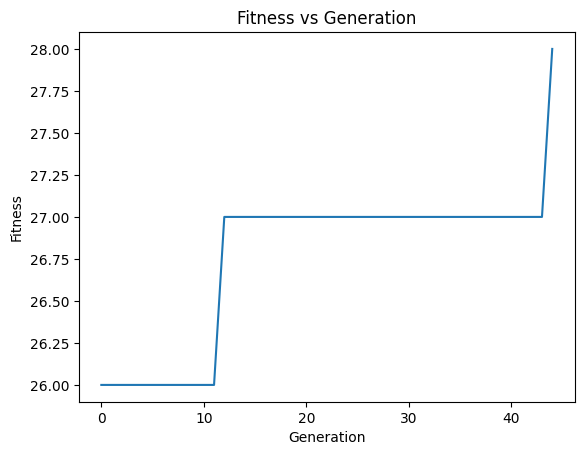

In [31]:
import random
import matplotlib.pyplot as plt
N = 8
POP_SIZE = 10
Pc = 0.8
Pm = 0.05
MAX_GENERATIONS = 500
MAX_FITNESS = 28

# Create valid chromosome 
def create_chromosome():
    chromosome = list(range(1, N+1))#create list 
    random.shuffle(chromosome)#shuffle this sorted list
    return chromosome

# Fitness function
def fitness(chromosome):
    attacking = 0
    for i in range(N):
        for j in range(i+1, N): 
#because index is not repeat so no column repeat
            # Row attack
            if chromosome[i] == chromosome[j]:#if row same attack is exist
                attacking += 1
            # Diagonal attack
            #abs(row1-row2)==abs(col1-col2)
            if abs(chromosome[i] - chromosome[j]) == abs(i - j):
                attacking += 1

    return MAX_FITNESS - attacking

# Initial population
def initial_population():
    return [create_chromosome() for _ in range(POP_SIZE)]#create populations 

def roulette_selection(population):
    fitness_values = [fitness(ind) for ind in population]
    total_fitness = sum(fitness_values)

    # Avoid zero division + better distribution
    probs = [(f + 1) / (total_fitness + POP_SIZE) for f in fitness_values]
    return population[random.choices(range(POP_SIZE), weights=probs)[0]]
def crossover(parent1, parent2):

    if random.random() > Pc:
        return parent1[:], parent2[:]
    point = random.randint(1, N-2)#generate point for single crossover
    child1 = parent1[:point]#pic fist part of parent one
    child2 = parent2[:point]#pic first part of parent 2
    # Fill remaining without duplicates
    for x in parent2:
        if x not in child1:#now fist part of child is parent so put second part of parent 2
            child1.append(x)
    for x in parent1:#now fist part of child is parent so put second part of parent 1
        if x not in child2:
            child2.append(x)

    return child1, child2

def mutation(chromosome):
    if random.random() < Pm:
        i, j = random.sample(range(N), 2)
        chromosome[i], chromosome[j] = chromosome[j], chromosome[i]
    return chromosome

# Print board
def print_board(chromosome):
    board = [["." for _ in range(N)] for _ in range(N)]

    for col in range(N):
        row = chromosome[col] - 1
        board[row][col] = "Q"

    print("\nFinal Chess Board:\n")
    for row in board:
        print(" ".join(row))

# Genetic Algorithm
def genetic_algorithm():

    population = initial_population()

    print("Initial Population:\n")
    for ind in population:
        print(ind, "Fitness:", fitness(ind))
    fitness_history = []
    for generation in range(MAX_GENERATIONS):
        fitness_values = [fitness(ind) for ind in population]
        max_fit = max(fitness_values)
        avg_fit = sum(fitness_values) / POP_SIZE
        print(f"Generation {generation} | Max Fitness = {max_fit} | Avg Fitness = {avg_fit:.2f}")
        fitness_history.append(max_fit)

        # STOP if solution found
        if max_fit == MAX_FITNESS:
            solution = population[fitness_values.index(max_fit)]
            return solution, fitness_history

        # preserve best
        best_ind = population[fitness_values.index(max_fit)]
        new_population = [best_ind]

        # Generate rest
        while len(new_population) < POP_SIZE:
            parent1 = roulette_selection(population)
            parent2 = roulette_selection(population)
            # avoid same parents 
            while parent1 == parent2:
                parent2 = roulette_selection(population)
            child1, child2 = crossover(parent1, parent2)
            child1 = mutation(child1)
            child2 = mutation(child2)

            if len(new_population) < POP_SIZE:
                new_population.append(child1)
            if len(new_population) < POP_SIZE:
                new_population.append(child2)

        population = new_population

    return population[0], fitness_history



solution, history = genetic_algorithm()

print("\nWinning Chromosome:", solution)
print("Fitness:", fitness(solution))

print_board(solution)

# Plot graph
plt.plot(history)
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Fitness vs Generation")
plt.show()